In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split

from sklearn.metrics import (
    accuracy_score, precision_score, fbeta_score,
    confusion_matrix, classification_report
)



In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cpu


In [3]:
dataset_dir = "Dataset"

In [4]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor()
])


full_dataset = datasets.ImageFolder(dataset_dir, transform=transform)

class_names = full_dataset.classes
print("Classes:", class_names)



Classes: ['Cyst', 'Normal', 'Tumor']


In [5]:
total_size = len(full_dataset)

train_size = int(0.7 * total_size)
val_size   = int(0.15 * total_size)
test_size  = total_size - train_size - val_size

train_data, val_data, test_data = random_split(
    full_dataset, [train_size, val_size, test_size]
)


train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_data, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_data, batch_size=32, shuffle=False)


model = models.alexnet(pretrained=True)

for param in model.features.parameters():
    param.requires_grad = False

model.classifier[6] = nn.Linear(4096, len(class_names))
model = model.to(device)


criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)



C:\Users\FABHOSTPYTHON\anaconda3\envs\weed\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\FABHOSTPYTHON\anaconda3\envs\weed\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [6]:

epochs = 5

train_loss_list = []
train_acc_list = []
val_acc_list = []

best_val_acc = 0

for epoch in range(epochs):

    # -------- TRAIN --------
    model.train()
    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / len(train_loader)
    train_acc = correct / total

    train_loss_list.append(train_loss)
    train_acc_list.append(train_acc)

    # -------- VALIDATION --------
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_acc = correct / total
    val_acc_list.append(val_acc)

    print(f"Epoch [{epoch+1}/{epochs}] "
          f"Loss: {train_loss:.4f} "
          f"Train Acc: {train_acc:.4f} "
          f"Val Acc: {val_acc:.4f}")

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_kidney_alexnet.pth")

print("✅ Training Completed!")



Epoch [1/5] Loss: 0.3235 Train Acc: 0.8703 Val Acc: 0.9819
Epoch [2/5] Loss: 0.1013 Train Acc: 0.9606 Val Acc: 0.9934
Epoch [3/5] Loss: 0.0630 Train Acc: 0.9788 Val Acc: 0.9994
Epoch [4/5] Loss: 0.0493 Train Acc: 0.9823 Val Acc: 0.9994
Epoch [5/5] Loss: 0.0359 Train Acc: 0.9866 Val Acc: 1.0000
✅ Training Completed!


In [7]:

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())




In [8]:
accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average='weighted')
f2 = fbeta_score(all_labels, all_preds, beta=2, average='weighted')

print("\n📊 RESULTS")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("F2 Score:", f2)

print("\n📄 Classification Report:\n")
print(classification_report(all_labels, all_preds, target_names=class_names))



📊 RESULTS
Accuracy: 0.9993979530403372
Precision: 0.9993990339145915
F2 Score: 0.999397866481045

📄 Classification Report:

              precision    recall  f1-score   support

        Cyst       1.00      1.00      1.00       556
      Normal       1.00      1.00      1.00       742
       Tumor       1.00      1.00      1.00       363

    accuracy                           1.00      1661
   macro avg       1.00      1.00      1.00      1661
weighted avg       1.00      1.00      1.00      1661



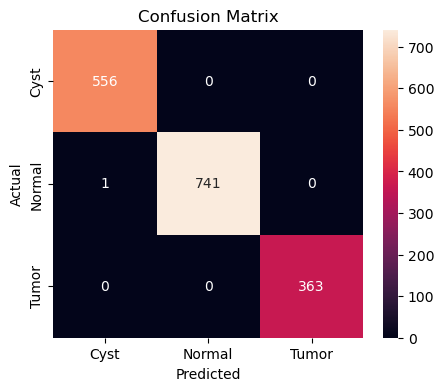

In [9]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


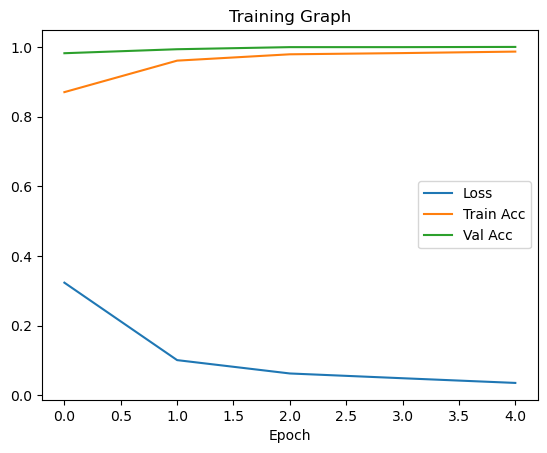

In [10]:
plt.figure()
plt.plot(train_loss_list, label="Loss")
plt.plot(train_acc_list, label="Train Acc")
plt.plot(val_acc_list, label="Val Acc")
plt.legend()
plt.title("Training Graph")
plt.xlabel("Epoch")
plt.show()

In [12]:
import torch
import torch.nn as nn
from torchvision import transforms, models
from PIL import Image


model_path = "best_kidney_alexnet.pth"
image_path = r"Dataset/Normal/Normal- (3).jpg"   


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class_names = ['Cyst', 'Normal', 'Tumor']


model = models.alexnet(pretrained=False)
model.classifier[6] = nn.Linear(4096, len(class_names))

model.load_state_dict(torch.load(model_path, map_location=device))
model = model.to(device)
model.eval()

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])


image = Image.open(image_path).convert("RGB")
image = transform(image).unsqueeze(0).to(device)

with torch.no_grad():
    outputs = model(image)
    _, pred = torch.max(outputs, 1)

predicted_class = class_names[pred.item()]

print("✅ Predicted Class:", predicted_class)

✅ Predicted Class: Normal
